**1. IMPORT**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

**2. LOAD DATA**

In [4]:
# load dataset
df = pd.read_excel("/content/dataset_udara.xlsx")

print("=== INFORMASI DATA ===")
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("\nNama Kolom:")
print(df.columns)

print("\nTipe Data:")
print(df.dtypes)

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nMissing Value:")
print(df.isnull().sum())

=== INFORMASI DATA ===
Jumlah data: 701
Jumlah kolom: 10

Nama Kolom:
Index(['id_data', 'kelembaban', 'mq135', 'mq2', 'status_kelembaban',
       'status_mq135', 'status_mq2', 'status_suhu', 'suhu', 'timestamp'],
      dtype='object')

Tipe Data:
id_data               object
kelembaban           float64
mq135                  int64
mq2                    int64
status_kelembaban     object
status_mq135          object
status_mq2            object
status_suhu           object
suhu                 float64
timestamp             object
dtype: object

Statistik Deskriptif:
       kelembaban        mq135          mq2        suhu
count  701.000000   701.000000   701.000000  701.000000
mean    83.274465  2075.990014  2209.776034   31.599287
std      1.449144  1427.033641  1312.401895    0.451236
min     79.600000   885.000000  1111.000000   31.000000
25%     82.200000   998.000000  1271.000000   31.100000
50%     83.600000  1103.000000  1328.000000   31.500000
75%     84.700000  4095.000000  40

**3. PROCESSING**

In [5]:
# hapus kolom yang tidak digunakan
df = df.drop(columns=["id_data", "timestamp"], errors='ignore')

# handle missing value
df = df.dropna()

# pilih fitur numerik
X = df[["mq135", "mq2", "suhu", "kelembaban"]]

# normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data preprocessing selesai")

Data preprocessing selesai


**4. EDA**

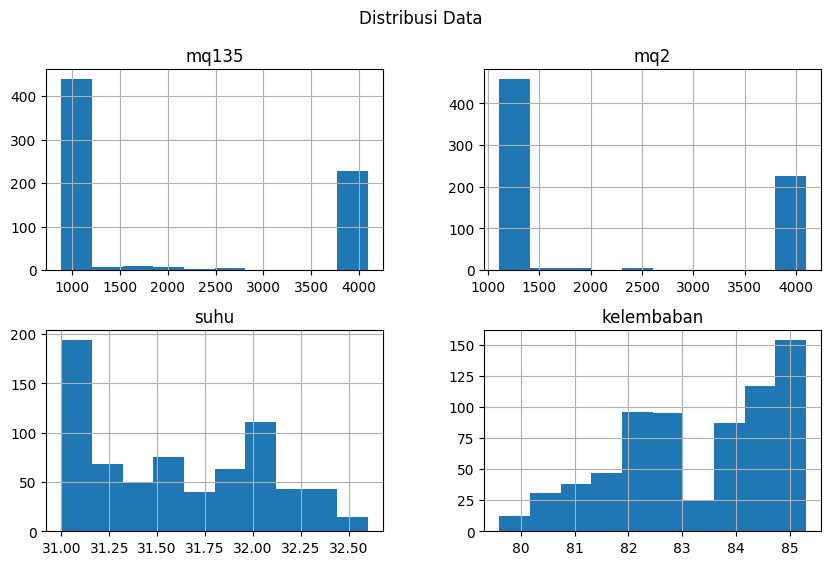

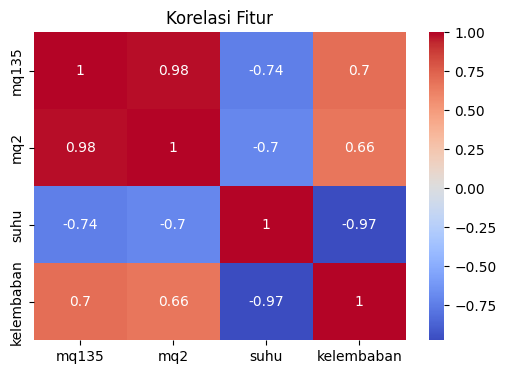

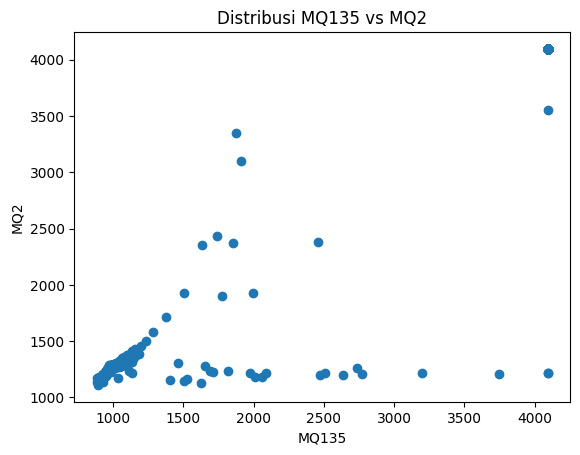

In [6]:
# distribusi data
X.hist(figsize=(10,6))
plt.suptitle("Distribusi Data")
plt.show()

# korelasi
plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Fitur")
plt.show()

# scatter plot
plt.scatter(X["mq135"], X["mq2"])
plt.xlabel("MQ135")
plt.ylabel("MQ2")
plt.title("Distribusi MQ135 vs MQ2")
plt.show()

**5. DATA SPLITTING**

In [7]:
splits = {
    "70:30": X_scaled[:int(0.7*len(X_scaled))],
    "80:20": X_scaled[:int(0.8*len(X_scaled))],
    "90:10": X_scaled[:int(0.9*len(X_scaled))]
}


**6. MODEL BUILDING**

In [8]:
print("\n=== MODEL BUILDING AWAL ===")

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
label_km = kmeans.fit_predict(X_scaled)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3)
label_agg = agg.fit_predict(X_scaled)

# DBSCAN
dbs = DBSCAN(eps=0.5, min_samples=5)
label_db = dbs.fit_predict(X_scaled)

print("Model awal berhasil dibuat")


=== MODEL BUILDING AWAL ===
Model awal berhasil dibuat


**7. HYPERPARAMETER TUNING**

In [9]:
best_score = -1
best_k = 0
print("\nK-MEANS")
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Silhouette={score}")

    if score > best_score:
        best_score = score
        best_k = k
print("Best K:", best_k)

best_score = -1
best_eps = 0

print("\nADBSCAN")
for eps in [0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    if len(set(labels)) > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"eps={eps}, score={score}")

        if score > best_score:
            best_score = score
            best_eps = eps
print("Best eps DBSCAN:", best_eps)

best_score = -1
best_linkage = ""

print("\nAgglomerative")
for linkage in ["ward", "complete", "average"]:
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels = agg.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    print(f"linkage={linkage}, score={score}")

    if score > best_score:
        best_score = score
        best_linkage = linkage

print("Best linkage Agglomerative:", best_linkage)


K-MEANS
K=2, Silhouette=0.712182128926401
K=3, Silhouette=0.6713071273571749
K=4, Silhouette=0.6632066552120914
K=5, Silhouette=0.6262261289356932
Best K: 2

ADBSCAN
eps=0.3, score=0.4333802863419737
eps=0.5, score=0.5031690115142942
eps=0.7, score=0.4096508500299879
eps=1.0, score=0.6555940690567015
Best eps DBSCAN: 1.0

Agglomerative
linkage=ward, score=0.6800654453151196
linkage=complete, score=0.4092452236346201
linkage=average, score=0.6349218867283195
Best linkage Agglomerative: ward


**8. MODEL & EVALUASI**

In [10]:
hasil = []

for nama_split, data in splits.items():

    # KMeans (pakai tuning)
    km = KMeans(n_clusters=best_k, random_state=42)
    label_km = km.fit_predict(data)

    sil_km = silhouette_score(data, label_km)
    db_km  = davies_bouldin_score(data, label_km)

    hasil.append({"Split": nama_split, "Algoritma": "K-Means",
                  "Silhouette": sil_km, "DB Index": db_km})

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
    label_agg = agg.fit_predict(data)

    sil_agg = silhouette_score(data, label_agg)
    db_agg  = davies_bouldin_score(data, label_agg)

    hasil.append({"Split": nama_split, "Algoritma": "Agglomerative",
                  "Silhouette": sil_agg, "DB Index": db_agg})

    # DBSCAN
    dbs = DBSCAN(eps=best_eps)
    label_dbs = dbs.fit_predict(data)

    if len(set(label_dbs)) > 1:
        sil_dbs = silhouette_score(data, label_dbs)
        db_dbs  = davies_bouldin_score(data, label_dbs)
    else:
        sil_dbs = 0
        db_dbs  = 0

    hasil.append({"Split": nama_split, "Algoritma": "DBSCAN",
                  "Silhouette": sil_dbs, "DB Index": db_dbs})

df_hasil = pd.DataFrame(hasil)

print("\n=== HASIL PER SPLIT ===")
print(df_hasil)


=== HASIL PER SPLIT ===
   Split      Algoritma  Silhouette  DB Index
0  70:30        K-Means    0.638314  0.433994
1  70:30  Agglomerative    0.586063  0.436428
2  70:30         DBSCAN    0.601818  0.351464
3  80:20        K-Means    0.686517  0.349182
4  80:20  Agglomerative    0.626454  0.411569
5  80:20         DBSCAN    0.635444  0.348218
6  90:10        K-Means    0.688565  0.384515
7  90:10  Agglomerative    0.654215  0.433963
8  90:10         DBSCAN    0.638759  0.364692


**9. VISUALISASI CLUSTER**

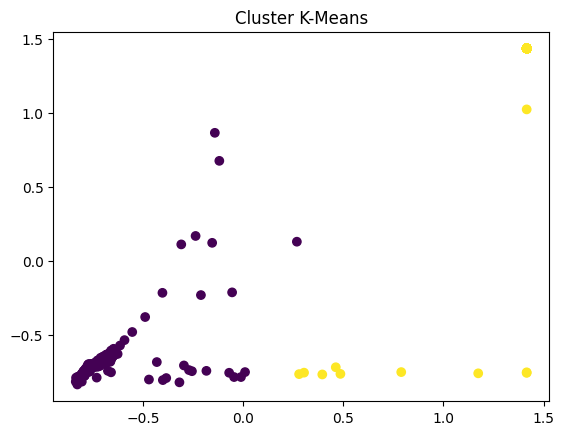

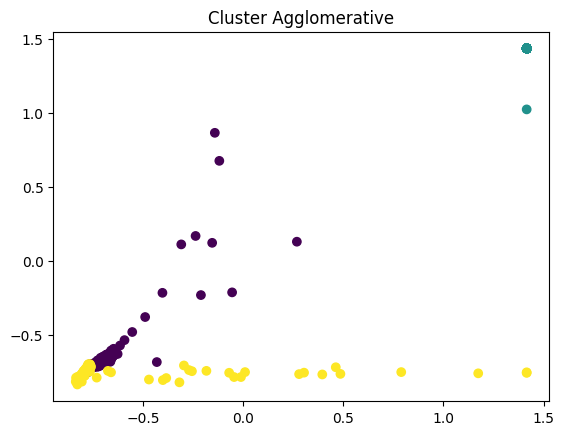

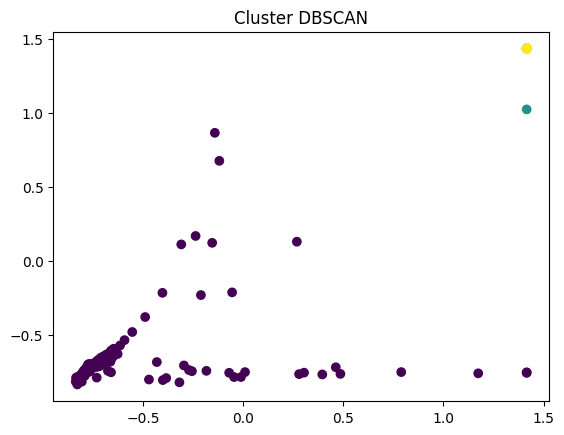

In [11]:
# KMeans
km = KMeans(n_clusters=best_k)
label_km = km.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_km)
plt.title("Cluster K-Means")
plt.show()

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
label_agg = agg.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_agg)
plt.title("Cluster Agglomerative")
plt.show()

# DBSCAN
dbs = DBSCAN(eps=best_eps)
label_db = dbs.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_db)
plt.title("Cluster DBSCAN")
plt.show()

**10. COMPARISON**


=== MODEL COMPARISON ===
       Algoritma  Silhouette Score  Davies-Bouldin Index
0        K-Means          0.688565              0.384515
1  Agglomerative          0.654215              0.433963
2         DBSCAN          0.638759              0.364692


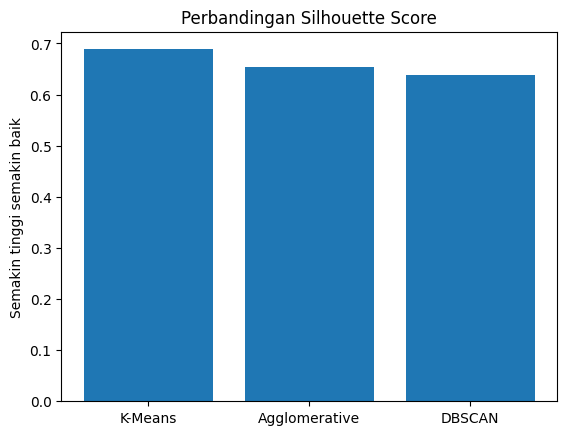

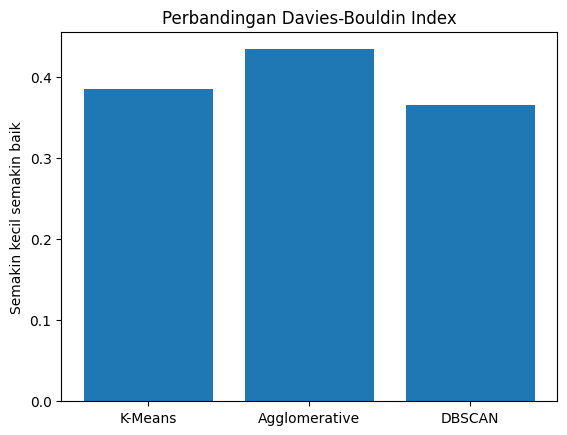


=== SILHOUETTE PER SPLIT ===
Split             70:30     80:20     90:10
Algoritma                                  
Agglomerative  0.586063  0.626454  0.654215
DBSCAN         0.601818  0.635444  0.638759
K-Means        0.638314  0.686517  0.688565

=== DB INDEX PER SPLIT ===
Split             70:30     80:20     90:10
Algoritma                                  
Agglomerative  0.436428  0.411569  0.433963
DBSCAN         0.351464  0.348218  0.364692
K-Means        0.433994  0.349182  0.384515


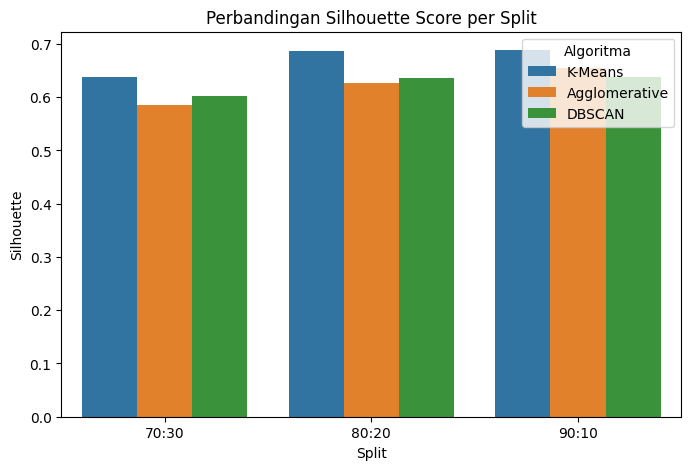

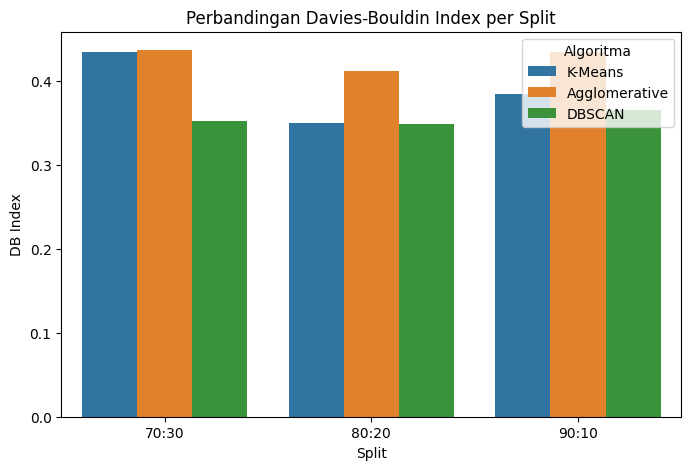

In [18]:
# =========================
# MODEL COMPARISON
# =========================
hasil_compare = pd.DataFrame({
    "Algoritma": ["K-Means", "Agglomerative", "DBSCAN"],
    "Silhouette Score": [sil_km, sil_agg, sil_dbs],
    "Davies-Bouldin Index": [db_km, db_agg, db_dbs]
})

print("\n=== MODEL COMPARISON ===")
print(hasil_compare)
# =========================
# GRAFIK PERFORMA ALGORITMA
# =========================
plt.figure()
plt.bar(hasil_compare["Algoritma"], hasil_compare["Silhouette Score"])
plt.title("Perbandingan Silhouette Score")
plt.ylabel("Semakin tinggi semakin baik")
plt.show()

plt.figure()
plt.bar(hasil_compare["Algoritma"], hasil_compare["Davies-Bouldin Index"])
plt.title("Perbandingan Davies-Bouldin Index")
plt.ylabel("Semakin kecil semakin baik")
plt.show()
# =========================
# PERBANDINGAN PER SPLIT
# =========================
pivot_sil = df_hasil.pivot(index="Algoritma", columns="Split", values="Silhouette")
pivot_db  = df_hasil.pivot(index="Algoritma", columns="Split", values="DB Index")

print("\n=== SILHOUETTE PER SPLIT ===")
print(pivot_sil)

print("\n=== DB INDEX PER SPLIT ===")
print(pivot_db)
# =========================
# GRAFIK PER SPLIT
# =========================
plt.figure(figsize=(8,5))
sns.barplot(data=df_hasil, x="Split", y="Silhouette", hue="Algoritma")
plt.title("Perbandingan Silhouette Score per Split")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df_hasil, x="Split", y="DB Index", hue="Algoritma")
plt.title("Perbandingan Davies-Bouldin Index per Split")
plt.show()